In [ ]:
pip install pillow

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import kagglehub
import os
import random
from PIL import Image

In [ ]:
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
path = ".."+path+"/New Plant Diseases Dataset(Augmented)"+"/New Plant Diseases Dataset(Augmented)"
train_path = path+"/train"
val_path = path+"/valid"


Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.


Strawberry___healthy
256
256


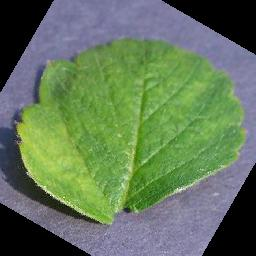

In [ ]:
classes = [name for name in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, name))]
class_name = random.choice(classes)
class_path = os.path.join(train_path, class_name)
img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

img = Image.open(img_path)

print(class_name)
print(img.width)
print(img.height)
img

In [ ]:
import torch

In [ ]:

import torch
import torch.nn as nn

In [ ]:
len(classes)

38

In [ ]:
from torch.utils.data import Dataset,DataLoader
from torchvision import datasets,transforms

In [ ]:
data_transformer=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[224], std=[224])
])

In [ ]:
train_dataset=datasets.ImageFolder(root=train_path,transform=None)

In [ ]:
valid_dataset=datasets.ImageFolder(root=val_path,transform=None)

In [ ]:
len(train_dataset),len(valid_dataset)

(70295, 17572)

In [ ]:
transformed_img=data_transformer(img)
print(transformed_img)

tensor([[[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]],

        [[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]],

        [[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]]])


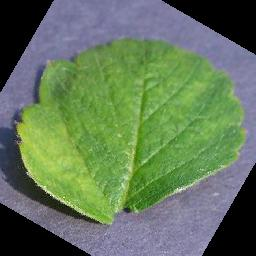

In [ ]:
img

In [ ]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True,num_workers=2)
valid_loader=DataLoader(valid_dataset,batch_size=32,shuffle=False,num_workers=2)

In [ ]:
len(train_loader),len(valid_loader)

(2197, 550)

In [ ]:
device="cuda"if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
dummy_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [ ]:
train_dataset = datasets.ImageFolder(root = train_path, transform=dummy_transform)

In [ ]:
def compute_mean_std(dataset, batch_size=16, num_workers=2):
  loader = DataLoader(dataset, batch_size=batch_size, shuffle = False, num_workers=2)
  channel_sum = torch.zeros(3, device=device)
  channel_sqsum = torch.zeros(3, device=device)
  pixel_count = 0

  for x, _ in loader:
    x = x.to(device)
    b, c, h, w = x.shape
    pixel_count+= h * w * b
    channel_sum += x.sum(dim=[0, 2, 3])
    channel_sqsum += (x**2).sum(dim=[0, 2, 3])

  mean = channel_sum / pixel_count
  std = torch.sqrt(channel_sqsum/ pixel_count - mean ** 2)
  return  mean, std

In [ ]:
mean, std = compute_mean_std(train_dataset)
mean = mean.tolist()
std = std.tolist()

In [ ]:
mean, std

([0.47596338391304016, 0.5003822445869446, 0.42664194107055664],
 [0.21028108894824982, 0.18884526193141937, 0.22626696527004242])

In [ ]:
from torchvision import transforms, datasets


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std =std)
])

In [ ]:


test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std =std)
])

In [ ]:
train_dataset = datasets.ImageFolder(root = train_path, transform=train_transform)


In [ ]:
 test_dataset = datasets.ImageFolder(root = train_path, transform=test_transform)

In [ ]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True,num_workers=2)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False,num_workers=2)

In [ ]:
class SimpleCNN(nn.Module):
  def __init__(self,in_features,out_features,hidden_units):
    super().__init__()
    self.layer=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=in_features,out_features=hidden_units),
        nn.Linear(in_features=hidden_units,out_features=out_features)
    )
  def forward(self,x):
    return self.layer(x)

In [ ]:
simpleCNN=SimpleCNN(3*224*224,38,256)
simpleCNN=simpleCNN.to(device)

In [ ]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(simpleCNN.parameters(),lr=0.01)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to device
simpleCNN = simpleCNN.to(device)

torch.manual_seed(42)
epochs = 2   # fixed variable naming

for epoch in range(epochs):
    print(f"Epoch: {epoch+1}")
    print("----------------------")
    train_loss = 0
    test_loss = 0

    simpleCNN.train()  # training mode
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        y_pred = simpleCNN(x)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()   # use .item() for scalars

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(train_loader)

    simpleCNN.eval()  # evaluation mode
    with torch.inference_mode():
        for x_test, y_test in test_loader:
            x_test, y_test = x_test.to(device), y_test.to(device)
            y_test_pred = simpleCNN(x_test)
            test_loss += loss_fn(y_test_pred, y_test).item()

        test_loss /= len(test_loader)

    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")


Epoch: 1
----------------------
Train Loss: 2.2041 | Test Loss: 1.8228
Epoch: 2
----------------------
Train Loss: 1.6804 | Test Loss: 1.9394


In [ ]:
class SimpleCNN(nn.Module):
  def __init__(self, num_classes=38):
    super(SimpleCNN, self).__init__()
    self.conv_layers=nn. Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2)
    )
    self.fc_layers=nn.Sequential(
        nn.Flatten(),
        nn.Linear(128*28*28,256),
        nn.ReLU(),
        nn.Linear(256, num_classes)
    )
  def forward(self, x):
    x=self.conv_layers(x)
    x=self.fc_layers(x)
    return x

device='cuda'if torch.cuda.is_available() else'cpu'
model=SimpleCNN(num_classes=38).to(device)

In [ ]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.01)

In [ ]:
num_epochs=5
for epoch in range(num_epochs):
  model.train()
  total_loss,correct,total=0.0,0,0

  for images,labels in train_loader:
    images,labels=images.to(device),labels.to(device)

    optimizer.zero_grad()
    outputs=model(images)
    loss = loss_fn(outputs, labels)

    loss.backward()
    optimizer.step()

    train_loss += loss.item()
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

  train_acc = 100 * correct / total
  avg_train_loss = train_loss / len(train_loader)

# Validation
model.eval()
val_loss, val_correct, val_total = 0.0, 0, 0
with torch.no_grad():
  for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    loss = loss_fn(outputs, labels)

    val_loss += loss.item()
    _, predicted = torch.max(outputs, 1)
    val_total += labels.size(0)
    val_correct += (predicted == labels).sum().item()

val_acc = 100 * val_correct / val_total
avg_val_loss = val_loss / len(test_loader)

print(f"Epoch [{epoch+1}/{num_epochs}] "
      f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}% "
      f"| Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%")


Epoch [5/5] Train Loss: 2.0343, Train Acc: 98.01% | Val Loss: 0.0482, Val Acc: 98.50%


In [ ]:
model.eval()

SimpleCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=38, bias=True)
  )
)

In [ ]:
torch.save(model.state_dict(), "cnn_weights.pth")
print("Model weights saved")

Model weights saved


In [ ]:
# Recreate the same model architecture
loaded_model = SimpleCNN().to(device)
loaded_model.load_state_dict(torch.load("cnn_weights.pth"))
loaded_model.eval()  # set model to evaluation mode
print("Model weights loaded")

Model weights loaded


In [ ]:
# test transforms
from PIL import Image
from torchvision import transforms

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

In [ ]:
#prediction function
def predict_image(img_path, model, class_names):
    image = Image.open(img_path).convert("RGB")
    image = test_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        _, predicted = torch.max(outputs, 1)

    return class_names[predicted.item()]


In [ ]:
class_names = train_loader.dataset.classes
img_path = "/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Blueberry___healthy/00fee259-67b7-4dd7-8b36-12503bbdba14___RS_HL 2681_180deg.JPG"
prediction = predict_image(img_path, loaded_model, class_names)
print("Predicted Class:", prediction)

Predicted Class: Squash___Powdery_mildew


In [ ]:
for i in range(5):  # check first 5 samples
    img, label = test_loader.dataset[i]
    img_path = test_loader.dataset.samples[i][0]  # path of image
    pred = predict_image(img_path, loaded_model, train_loader.dataset.classes)
    print(f"Image: {img_path} | Actual: {train_loader.dataset.classes[label]} | Predicted: {pred}")


Image: ../kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Apple___Apple_scab/00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG | Actual: Apple___Apple_scab | Predicted: Squash___Powdery_mildew
Image: ../kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Apple___Apple_scab/01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG | Actual: Apple___Apple_scab | Predicted: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Image: ../kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Apple___Apple_scab/01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003_270deg.JPG | Actual: Apple___Apple_scab | Predicted: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Image: ../kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset

In [ ]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = loaded_model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"✅ Test Accuracy: {accuracy:.2f}%")

✅ Test Accuracy: 100.00%
